# CNN-BiLSTM with FastText

In [ ]:
!pip install dagshub mlflow gensim -q

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D, GlobalAveragePooling1D, SpatialDropout1D, Conv1D, Concatenate, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import regularizers

sns.set_theme(style='whitegrid')
print("Libraries imported.")

# Detect Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research'
    if not os.path.exists(PROJECT_ROOT):
        PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research'
    os.chdir(PROJECT_ROOT)
    print(f"Running in Google Colab. Current dir: {os.getcwd()}")
else:
    # Running locally
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print(f"Running locally. Project root: {PROJECT_ROOT}")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import mlflow
import mlflow.tensorflow
import dagshub

dagshub.init(repo_owner='raflialfansyah', repo_name='lentera1', mlflow=True)
mlflow.set_experiment('CNN_BiLSTM_Urgency_v2')
mlflow.tensorflow.autolog()
mlflow.start_run(run_name='cnnbilstm_Run_v2')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=5850da96-cb19-40e5-93f9-85fa42e7ba1c&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=c387f387402e5995173166d9f0ea83f90c0af55e51538a0031544fda621a957e




Accessing as raflialfansyah

Initialized MLflow to track repo "raflialfansyah/lentera1"

Repository raflialfansyah/lentera1 initialized!

<ActiveRun: >

## 1. Data Loading & Sampling (Balanced 1:1:1)

In [ ]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'cleaned_complaints.csv')
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['Cleaned_Narrative', 'Urgency'])

df_high = df[df['Urgency'] == 'High']
df_medium = df[df['Urgency'] == 'Medium']
df_low = df[df['Urgency'] == 'Low']

min_class_size = df['Urgency'].value_counts().min()

if len(df_high) > min_class_size:
    df_high = df_high.sample(min_class_size, random_state=42)
if len(df_medium) > min_class_size:
    df_medium = df_medium.sample(min_class_size, random_state=42)

df = pd.concat([df_high, df_medium, df_low])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Class Distribution after balanced sampling:")
print(df['Urgency'].value_counts())


Class Distribution after balanced sampling:
Urgency
High      19431
Medium    19431
Low       19431
Name: count, dtype: int64


## 2. Label Encoding & Data Splitting

In [ ]:
label_encoder = LabelEncoder()
df['Urgency_Encoded'] = label_encoder.fit_transform(df['Urgency'])

X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    df['Cleaned_Narrative'], df['Urgency_Encoded'],
    test_size=0.20, random_state=42, stratify=df['Urgency_Encoded']
)
print(f"Train size: {len(X_train_texts)}, Test size: {len(X_test_texts)}")


Train size: 46634, Test size: 11659


## 3. Tokenization & Loading FastText Model

In [ ]:
max_vocab_size = 20000
max_length = 200

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['Cleaned_Narrative'])

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train_texts), maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test_texts), maxlen=max_length, padding='post', truncating='post')

from gensim.models import FastText
ft_model_path = os.path.join(PROJECT_ROOT, 'models', 'fasttext_urgency.model')
print(f"Loading FastText from {ft_model_path}...")
ft_model = FastText.load(ft_model_path)

word_index = tokenizer.word_index
embedding_dim = 200
num_words = min(max_vocab_size, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in word_index.items():
    if i >= max_vocab_size: continue
    try: embedding_matrix[i] = ft_model.wv[word]
    except KeyError: pass
print(f"Embedding matrix shape: {embedding_matrix.shape}")


Loading FastText from /content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research/models/fasttext_urgency.model...
Embedding matrix shape: (20000, 200)


## 4. Build CNN-BiLSTM Model Architecture

In [ ]:
input_layer = Input(shape=(max_length,), name='Input')
x = Embedding(input_dim=num_words, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False, name='Embedding')(input_layer)
x = SpatialDropout1D(0.3)(x)


x = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same', name='Conv1D')(x)

x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3), name='BiLSTM')(x)

avg_pool = GlobalAveragePooling1D(name='GlobalAveragePool')(x)
max_pool = GlobalMaxPooling1D(name='GlobalMaxPool')(x)
conc = Concatenate(name='Concatenate')([avg_pool, max_pool])

x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='Dense1')(conc)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='Dense2')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output_layer = Dense(len(label_encoder.classes_), activation='softmax', name='Output')(x)

model = Model(inputs=input_layer, outputs=output_layer, name='CNN_BiLSTM')
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 200)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 200, 200)  │  4,000,000 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 200, 200)  │          0 │ Embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1D (Conv1D)     │ (None, 200, 128)  │    128,128 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiLSTM              │ (None, 200, 256)  │    263,168 │ Conv1D[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GlobalAveragePool   │ (None, 256)       │          0 │ BiLSTM[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GlobalMaxPool       │ (None, 256)       │          0 │ BiLSTM[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concatenate         │ (None, 512)       │          0 │ GlobalAveragePoo… │
│ (Concatenate)       │                   │            │ GlobalMaxPool[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense1 (Dense)      │ (None, 128)       │     65,664 │ Concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ Dense1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense2 (Dense)      │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ Dense2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 3)         │        195 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,466,179 (17.04 MB)

 Trainable params: 465,795 (1.78 MB)

 Non-trainable params: 4,000,384 (15.26 MB)

## 5. Phase 1 Training (Frozen Embeddings)

In [ ]:
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights_array))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint('cnn_bilstm_phase1.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ModelCheckpoint('cnn_bilstm_phase1.h5', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history_phase1 = model.fit(
    X_train_pad, y_train, epochs=50, batch_size=64,
    validation_data=(X_test_pad, y_test),
    class_weight=class_weights_dict,
    callbacks=callbacks, verbose=1
)


2026/06/19 03:40:53 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


Epoch 1/50
729/729 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5312 - loss: 2.6971
Epoch 1: val_loss improved from None to 0.90302, saving model to cnn_bilstm_phase1.keras

Epoch 1: finished saving model to cnn_bilstm_phase1.keras

Epoch 1: val_loss improved from None to 0.90302, saving model to cnn_bilstm_phase1.h5



Epoch 1: finished saving model to cnn_bilstm_phase1.h5


729/729 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.6084 - loss: 1.8203 - val_accuracy: 0.6902 - val_loss: 0.9030 - learning_rate: 0.0010
Epoch 2/50
728/729 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7227 - loss: 0.7876
Epoch 2: val_loss improved from 0.90302 to 0.55233, saving model to cnn_bilstm_phase1.keras

Epoch 2: finished saving model to cnn_bilstm_phase1.keras

Epoch 2: val_loss improved from 0.90302 to 0.55233, saving model to cnn_bilstm_phase1.h5



Epoch 2: finished saving model to cnn_bilstm_phase1.h5


...


Epoch 11: finished saving model to cnn_bilstm_phase1.h5


729/729 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.8357 - loss: 0.4501 - val_accuracy: 0.8309 - val_loss: 0.4440 - learning_rate: 0.0010
Epoch 12/50
728/729 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8385 - loss: 0.4370
Epoch 12: val_loss did not improve from 0.44396

Epoch 12: val_loss did not improve from 0.44396
729/729 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.8371 - loss: 0.4422 - val_accuracy: 0.8293 - val_loss: 0.4597 - learning_rate: 0.0010
Epoch 13/50
728/729 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8397 - loss: 0.4356
Epoch 13: val_loss did not improve from 0.44396

Epoch 13: val_loss did not improve from 0.44396
729/729 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.8405 - loss: 0.4371 - val_accuracy: 0.8001 - val_loss: 0.5166 - learning_rate: 0.0010
Epoch 14/50
728/729 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8449 - loss: 0.4267
Epoch 14: val_loss did not improve from 0.44396

Epoch 14: val_loss did not improve from 0.44396

Epoch 14: Reduc


Epoch 16: finished saving model to cnn_bilstm_phase1.h5


729/729 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.8580 - loss: 0.3880 - val_accuracy: 0.8357 - val_loss: 0.4341 - learning_rate: 5.0000e-04
Epoch 17/50
728/729 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8572 - loss: 0.3847
Epoch 17: val_loss did not improve from 0.43411

Epoch 17: val_loss did not improve from 0.43411
729/729 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.8575 - loss: 0.3838 - val_accuracy: 0.8208 - val_loss: 0.4813 - learning_rate: 5.0000e-04
Epoch 18/50
729/729 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8616 - loss: 0.3734
Epoch 18: val_loss did not improve from 0.43411

Epoch 18: val_loss did not improve from 0.43411
729/729 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.8611 - loss: 0.3763 - val_accuracy: 0.8265 - val_loss: 0.4548 - learning_rate: 5.0000e-04
Epoch 19/50
728/729 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8633 - loss: 0.3737
Epoch 19: val_loss did not improve from 0.43411

Epoch 19: val_loss did not improve from 0.43411

Epo

2026/06/19 03:52:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## 6. Evaluation & Logging

Loaded Phase 1 best weights.
Model dictionary (architecture & weights) saved to cnn_bilstm_phase1.pkl
Tokenizer saved to cnn_bilstm_tokenizer.pkl
Label encoder saved to cnn_bilstm_label_encoder.pkl
365/365 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.84      0.89      3886
         Low       0.79      0.85      0.82      3886
      Medium       0.79      0.82      0.80      3887

    accuracy                           0.84     11659
   macro avg       0.84      0.84      0.84     11659
weighted avg       0.84      0.84      0.84     11659

Metrics logged to MLflow.


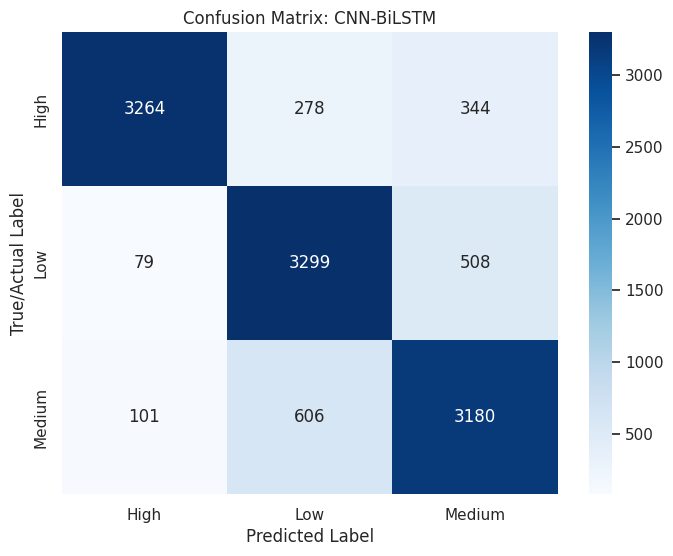

Model artifacts (.keras, .h5, .pkl, tokenizer, and label encoder) logged to DagsHub.
🏃 View run cnnbilstm_Run_v2 at: https://dagshub.com/raflialfansyah/lentera1.mlflow/#/experiments/7/runs/e290b7e4d15847b4b39b1cf7342447a6
🧪 View experiment at: https://dagshub.com/raflialfansyah/lentera1.mlflow/#/experiments/7
MLflow run for Phase 1 ended successfully.


In [ ]:
if os.path.exists('cnn_bilstm_phase1.keras'):
    model.load_weights('cnn_bilstm_phase1.keras')
    print("Loaded Phase 1 best weights.")

    import pickle
    model_dict = {
        'architecture': model.to_json(),
        'weights': model.get_weights()
    }
    with open('cnn_bilstm_phase1.pkl', 'wb') as f:
        pickle.dump(model_dict, f)
    print("Model dictionary (architecture & weights) saved to cnn_bilstm_phase1.pkl")

    with open('cnn_bilstm_tokenizer.pkl', 'wb') as f:
        pickle.dump(tokenizer, f)
    print("Tokenizer saved to cnn_bilstm_tokenizer.pkl")

    with open('cnn_bilstm_label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)
    print("Label encoder saved to cnn_bilstm_label_encoder.pkl")

y_pred_probs_p1 = model.predict(X_test_pad)
y_pred_p1 = np.argmax(y_pred_probs_p1, axis=1)


print("Classification Report:")
print(classification_report(y_test, y_pred_p1, target_names=label_encoder.classes_))

report_p1 = classification_report(y_test, y_pred_p1, target_names=label_encoder.classes_, output_dict=True)
for class_name, metrics in report_p1.items():
    if isinstance(metrics, dict):
        for metric_name, value in metrics.items():
            metric_key = f"{class_name}_{metric_name}".replace(" ", "_").replace("-", "_")
            mlflow.log_metric(metric_key, value)
    else:
        mlflow.log_metric(class_name.replace(" ", "_"), metrics)
print("Metrics logged to MLflow.")

cm_p1 = confusion_matrix(y_test, y_pred_p1)
plt.figure(figsize=(8,6))
sns.heatmap(cm_p1, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True/Actual Label')
plt.title('Confusion Matrix: CNN-BiLSTM')
plt.savefig('cnn_bilstm_phase1_confusion_matrix.png')
mlflow.log_artifact('cnn_bilstm_phase1_confusion_matrix.png', artifact_path='evaluation_plots')
plt.show()

# Akhiri logging eksperimen Phase 1
if os.path.exists('cnn_bilstm_phase1.keras'):
    mlflow.log_artifact('cnn_bilstm_phase1.keras', artifact_path='models')
    if os.path.exists('cnn_bilstm_phase1.h5'):
        mlflow.log_artifact('cnn_bilstm_phase1.h5', artifact_path='models')
    if os.path.exists('cnn_bilstm_phase1.pkl'):
        mlflow.log_artifact('cnn_bilstm_phase1.pkl', artifact_path='models')
    if os.path.exists('cnn_bilstm_tokenizer.pkl'):
        mlflow.log_artifact('cnn_bilstm_tokenizer.pkl', artifact_path='models')
    if os.path.exists('cnn_bilstm_label_encoder.pkl'):
        mlflow.log_artifact('cnn_bilstm_label_encoder.pkl', artifact_path='models')
    print('Model artifacts (.keras, .h5, .pkl, tokenizer, and label encoder) logged to DagsHub.')
mlflow.end_run()
print("MLflow run for Phase 1 ended successfully.")